# TP 04 :

Import des bibliothèques nécessaires

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Partie 01 : 
### a) Résolution de l'exercice des quantiles avec des calculs explicites : 

#### 1/ Les employés : 

In [21]:
salaire = np.array([1000, 1500, 2000, 3500, 12000])
# Calcul du salaire moyen : 
salaire_moyen = salaire.sum() / len(salaire)

# Calcul du salaire médian : (c'est la valeur centrale)
indice = int(((len(salaire) + 1) / 2)) 
salaire_median = salaire[indice - 1]    # car les indices commencent à 0

# En considérant que les 4 premiers salaires 
salaire_bis = salaire[:4]

salaire_moyen_bis = salaire_bis.sum() / len(salaire_bis)

indice_bis = int(len(salaire_bis) / 2) - 1 # -1 car on commence à 0
salaire_median_bis = (salaire_bis[indice_bis] + salaire_bis[indice_bis + 1]) / 2

print("Les salaires des cinq employés sont : ", salaire, "euros") 
print("Le salaire moyen est de : ", salaire_moyen, "euros")
print("Le salaire médian est de : ", salaire_median, "euros")
print("Les salaires des quatre employés sont : ", salaire_bis, "euros")
print("Le salaire moyen des quatres employés est de : ", salaire_moyen_bis, "euros")
print("Le salaire médian des quatres employés est de : ", salaire_median_bis, "euros")

Les salaires des cinq employés sont :  [ 1000  1500  2000  3500 12000] euros
Le salaire moyen est de :  4000.0 euros
Le salaire médian est de :  2000 euros
Les salaires des quatre employés sont :  [1000 1500 2000 3500] euros
Le salaire moyen des quatres employés est de :  2000.0 euros
Le salaire médian des quatres employés est de :  1750.0 euros


### b) Résolution de l'exercice des quantiles avec les outils de SciPy : 

## Partie 02 : 

### a) Simulation de 10000 lancers de 10 pièces équilibrées : 

### b)  histogramme du nombre de faces obtenues : 

## Partie 03 : 

### a) Analyse d'un dataset réel (La moyenne, l'écart type et les quartiles, Un histogramme classique) :

Simulation de lancer de pièce (pile=1, face=0)
Nombre d'essais simulés : 1000 séries de 10 lancers

→ Pour le nombre de piles obtenues :
  - Écart-type théorique : 1.5811
  - Écart-type empirique : 1.5901

→ Pour la proportion de piles :
  - Écart-type théorique : 0.1581
  - Écart-type empirique : 0.1590

→ Quartiles de la proportion de piles :
  - 1er quartile (25%) : 0.40
  - Médiane (50%) : 0.50
  - 3e quartile (75%) : 0.60
  - Maximum (100%) : 0.90


Text(0.751, 220.92, 'Moyenne = 0.50\nσ(emp) = 0.159\nσ(th) = 0.158')

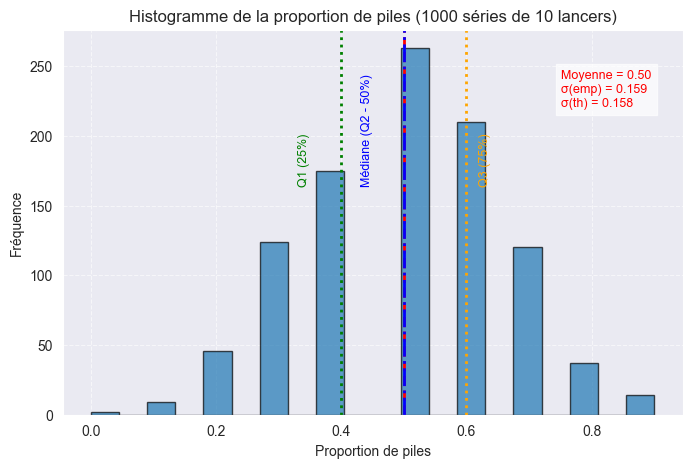

In [12]:
#  Paramètres de l'expérience
nombre_lancers = 10
p = 0.5
Nombres_echantillons = 1000

# --- Simulation des lancers ---
lancers = np.random.binomial(1, p, size=(Nombres_echantillons, nombre_lancers))

# --- Calculs ---
# Somme de piles par série
nb_piles = lancers.sum(axis=1)

# Proportion de piles par série
prop_piles = nb_piles / nombre_lancers

# Écart-type théorique et empirique
sigma_theorique_nombre = np.sqrt(nombre_lancers * p * (1 - p))
sigma_empirique_nombre = nb_piles.std(ddof=1)

sigma_theorique_proportion = np.sqrt(p * (1 - p) / nombre_lancers)
sigma_empirique_proportion = prop_piles.std(ddof=1)

moyenne = np.mean(prop_piles)
quartiles = np.percentile(prop_piles, [25, 50, 75, 100])
q1, q2, q3, q4 = quartiles

# --- Affichage des résultats ---
print("Simulation de lancer de pièce (pile=1, face=0)")
print(f"Nombre d'essais simulés : {Nombres_echantillons} séries de {nombre_lancers} lancers\n")
print("→ Pour le nombre de piles obtenues :")
print(f"  - Écart-type théorique : {sigma_theorique_nombre:.4f}")
print(f"  - Écart-type empirique : {sigma_empirique_nombre:.4f}\n")
print("→ Pour la proportion de piles :")
print(f"  - Écart-type théorique : {sigma_theorique_proportion:.4f}")
print(f"  - Écart-type empirique : {sigma_empirique_proportion:.4f}\n")
print("→ Quartiles de la proportion de piles :")
print(f"  - 1er quartile (25%) : {q1:.2f}")
print(f"  - Médiane (50%) : {q2:.2f}")
print(f"  - 3e quartile (75%) : {q3:.2f}")
print(f"  - Maximum (100%) : {q4:.2f}")

plt.figure(figsize=(8, 5))
plt.hist(prop_piles, bins=20, edgecolor='black', alpha=0.7)
plt.title("Histogramme de la proportion de piles (1000 séries de 10 lancers)")
plt.xlabel("Proportion de piles")
plt.ylabel("Fréquence")
plt.grid(True, linestyle='--', alpha=0.6)


plt.axvline(moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne = {moyenne:.2f}')
plt.axvline(q1, color='green', linestyle=':', linewidth=2, label=f'Q1 = {q1:.2f}')
plt.axvline(q2, color='blue', linestyle='-.', linewidth=2, label=f'Médiane = {q2:.2f}')
plt.axvline(q3, color='orange', linestyle=':', linewidth=2, label=f'Q3 = {q3:.2f}')
plt.text(q1 - 0.05, plt.ylim()[1]*0.6, "Q1 (25%)", color='green', rotation=90, fontsize=9, ha='right')
plt.text(q2 - 0.05, plt.ylim()[1]*0.6, "Médiane (Q2 - 50%)", color='blue', rotation=90, fontsize=9, ha='right')
plt.text(q3 + 0.02, plt.ylim()[1]*0.6, "Q3 (75%)", color='orange', rotation=90, fontsize=9, ha='left')
plt.text(moyenne + 0.25, plt.ylim()[1]*0.8,
         f"Moyenne = {moyenne:.2f}\nσ(emp) = {sigma_empirique_proportion:.3f}\nσ(th) = {sigma_theorique_proportion:.3f}",
         color='red', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

### b) un histogramme cumulatif :

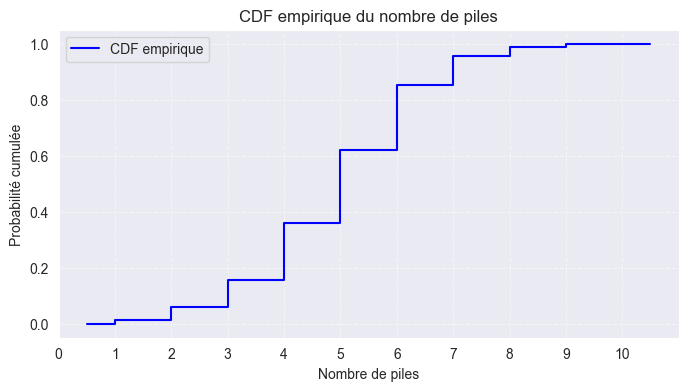

In [4]:
compte, bins = np.histogram(nb_piles, bins=np.arange(-0.5, nombre_lancers + 1.5, 1))
cdf = np.cumsum(compte) / compte.sum()

plt.figure(figsize=(8, 4))
plt.step(bins[1:], cdf, where='mid', color='blue', label='CDF empirique')
plt.title("CDF empirique du nombre de piles")
plt.xlabel("Nombre de piles")
plt.ylabel("Probabilité cumulée")
plt.xticks(range(0, nombre_lancers + 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()